# Research Results Gallery

This notebook loads the saved visual artifacts generated by the project pipelines and displays them in one place.

Coverage:
- deep classification benchmark figures
- ANN hazard-model figures
- clustering analysis figures


In [1]:
from pathlib import Path
import json
import math
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".svg"}

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "models"
CLS_DIR = MODELS_DIR / "classification"
ANN_DIR = MODELS_DIR / "ann"
CLUSTER_DIR = MODELS_DIR / "clustering"
COMPETE_DIR = MODELS_DIR / "competition"

print("project root:", PROJECT_ROOT)
print("models dir:", MODELS_DIR)

project root: D:\Github Desktop\ewaste_vit_project
models dir: D:\Github Desktop\ewaste_vit_project\models


In [2]:
def load_json(path: Path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as fp:
        return json.load(fp)

classification_metrics = load_json(CLS_DIR / "test_results.json") or load_json(CLS_DIR / "dl_results.json")
ann_metrics = load_json(ANN_DIR / "ann_results_18cls.json")
clustering_metrics = load_json(CLUSTER_DIR / "clustering_metrics.json")
competition_leaderboard = load_json(COMPETE_DIR / "leaderboard.json")
competition_deep = load_json(COMPETE_DIR / "deep_results.json")
competition_traditional = load_json(COMPETE_DIR / "traditional_ml_results.json")
competition_all_players = load_json(COMPETE_DIR / "all_players_results.json")

print("classification metrics:", "FOUND" if classification_metrics else "MISSING")
print("ann metrics:", "FOUND" if ann_metrics else "MISSING")
print("clustering metrics:", "FOUND" if clustering_metrics else "MISSING")
print("competition leaderboard:", "FOUND" if competition_leaderboard else "MISSING")
print("competition deep results:", "FOUND" if competition_deep else "MISSING")
print("competition traditional results:", "FOUND" if competition_traditional else "MISSING")

classification_metrics

classification metrics: FOUND
ann metrics: FOUND
clustering metrics: FOUND
competition leaderboard: FOUND
competition deep results: FOUND
competition traditional results: FOUND


{'resnet18': {'test_accuracy': 0.9678,
  'test_loss': 0.495,
  'macro_f1': 0.9678,
  'weighted_f1': 0.9678,
  'macro_precision': 0.9684,
  'macro_recall': 0.9678,
  'elapsed_seconds': 6223.23,
  'checkpoint': 'models/classification/resnet18/resnet18_best.pth'},
 'resnet50': {'test_accuracy': 0.9789,
  'test_loss': 0.4537,
  'macro_f1': 0.9789,
  'weighted_f1': 0.9789,
  'macro_precision': 0.9791,
  'macro_recall': 0.9789,
  'elapsed_seconds': 8150.52,
  'checkpoint': 'models/classification/resnet50/resnet50_best.pth'},
 'efficientnet_b0': {'test_accuracy': 0.9128,
  'test_loss': 1.0918,
  'macro_f1': 0.9115,
  'weighted_f1': 0.9115,
  'macro_precision': 0.9159,
  'macro_recall': 0.9128,
  'elapsed_seconds': 5356.05,
  'checkpoint': 'models/classification/efficientnet_b0/efficientnet_b0_best.pth'},
 'efficientnet_b3': {'test_accuracy': 0.9422,
  'test_loss': 0.5773,
  'macro_f1': 0.9419,
  'weighted_f1': 0.9419,
  'macro_precision': 0.9441,
  'macro_recall': 0.9422,
  'elapsed_seconds':

detailed confusion sources found in classification folder: 7


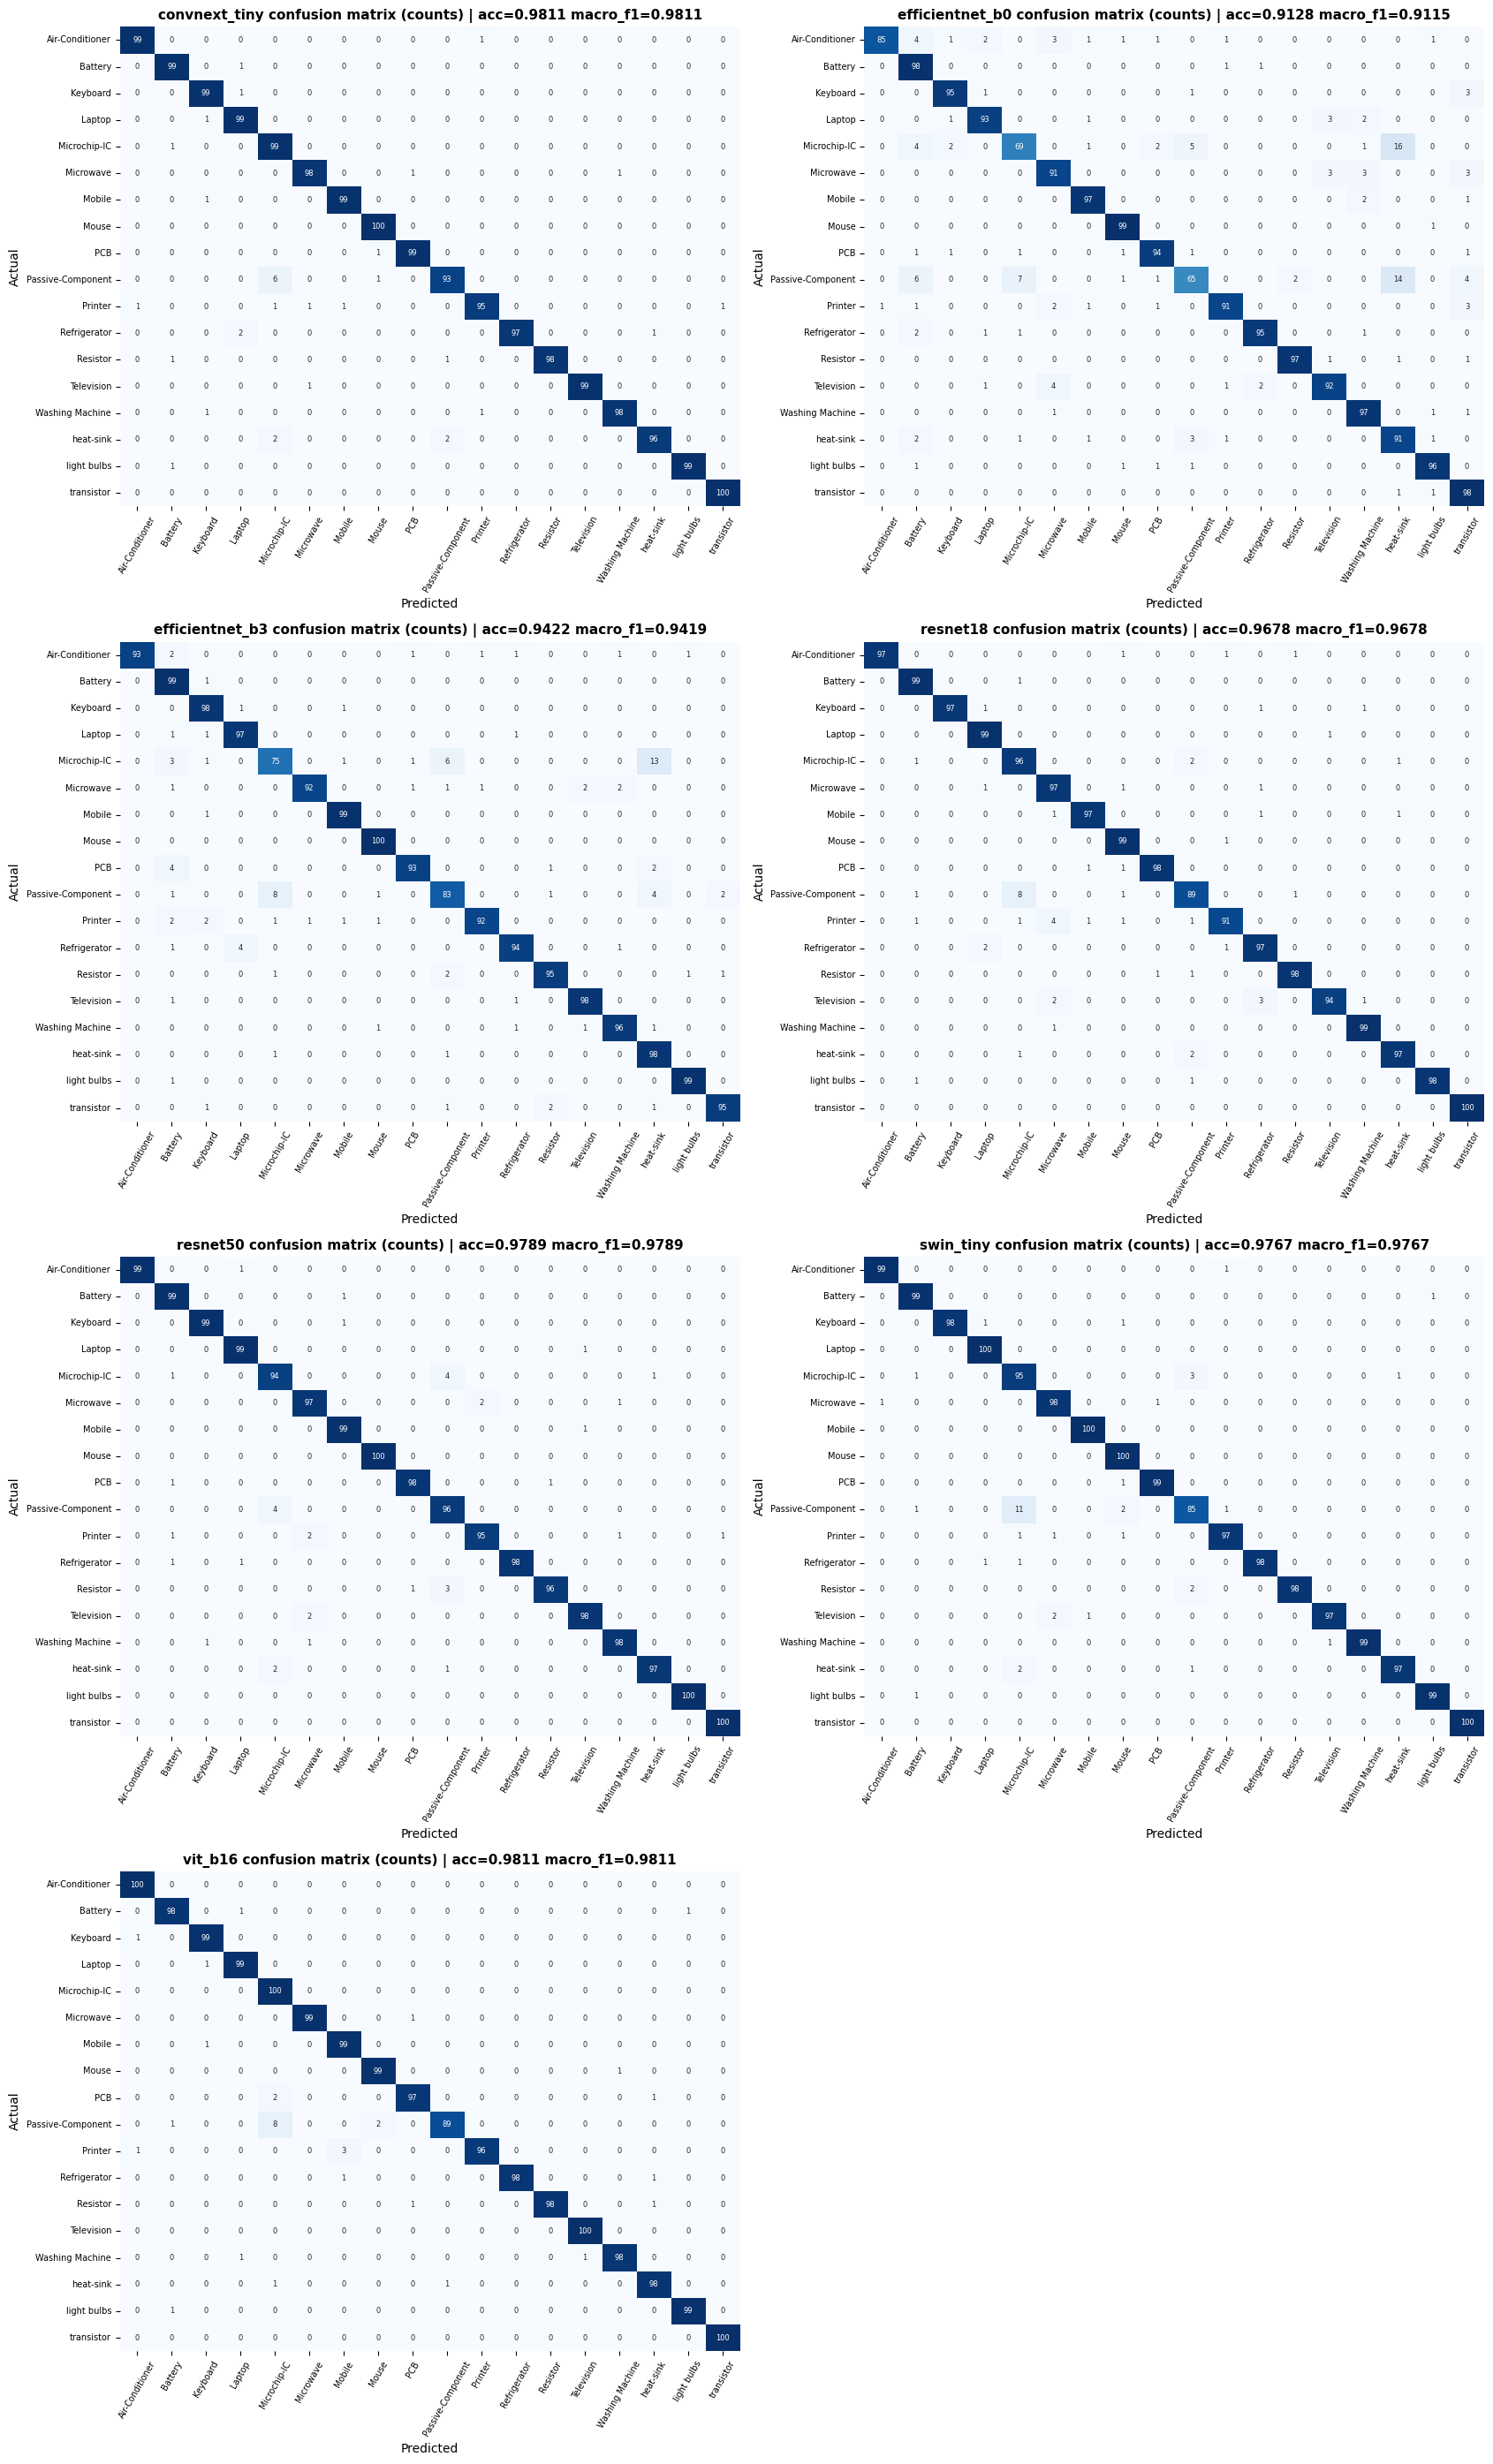

In [3]:
def discover_detailed_confusion_sources(include_competition_fallback=False):
    detailed = {}
    class_names = None

    # Preferred source: per-architecture classification payloads.
    for results_path in sorted(CLS_DIR.glob("*/results.json")):
        payload = load_json(results_path)
        if not isinstance(payload, dict):
            continue

        if ("confusion_matrix" in payload) or ("confusion_matrix_normalized" in payload):
            detailed[results_path.parent.name] = payload
            if class_names is None and isinstance(payload.get("class_names"), list):
                class_names = payload["class_names"]

    # Optional fallback to competition payloads if classification payloads are missing.
    if include_competition_fallback and not detailed:
        deep_payload = load_json(COMPETE_DIR / "deep_results.json")
        if isinstance(deep_payload, dict):
            for model_name, payload in deep_payload.items():
                if not isinstance(payload, dict):
                    continue
                if ("confusion_matrix" in payload) or ("confusion_matrix_normalized" in payload):
                    detailed[model_name] = payload
                    if class_names is None and isinstance(payload.get("class_names"), list):
                        class_names = payload["class_names"]

    # Class names fallback chain.
    if class_names is None:
        benchmark_summary = load_json(CLS_DIR / "benchmark_summary.json")
        if isinstance(benchmark_summary, dict) and isinstance(benchmark_summary.get("class_names"), list):
            class_names = benchmark_summary["class_names"]

    if class_names is None and include_competition_fallback:
        leaderboard = load_json(COMPETE_DIR / "leaderboard.json")
        if isinstance(leaderboard, dict) and isinstance(leaderboard.get("class_names"), list):
            class_names = leaderboard["class_names"]

    if class_names is None and detailed:
        sample_payload = next(iter(detailed.values()))
        sample_matrix = sample_payload.get("confusion_matrix") or sample_payload.get("confusion_matrix_normalized")
        if isinstance(sample_matrix, list):
            class_names = [f"class_{i}" for i in range(len(sample_matrix))]

    return detailed, class_names


def get_confusion_matrix(payload, normalized=False):
    key = "confusion_matrix_normalized" if normalized else "confusion_matrix"
    matrix = payload.get(key)

    if matrix is None and normalized and payload.get("confusion_matrix") is not None:
        raw = np.array(payload["confusion_matrix"], dtype=float)
        row_sums = raw.sum(axis=1, keepdims=True)
        matrix = np.divide(raw, row_sums, out=np.zeros_like(raw, dtype=float), where=row_sums != 0)

    if matrix is None:
        return None

    matrix_np = np.array(matrix, dtype=float)
    if normalized:
        return matrix_np
    return np.rint(matrix_np).astype(int)


def plot_annotated_confusion_matrices(detailed_payloads, class_names, normalized=False):
    if not detailed_payloads:
        print("No detailed confusion-matrix JSON found in models/classification/*/results.json")
        return

    model_names = list(detailed_payloads.keys())
    ncols = 2 if len(model_names) > 1 else 1
    nrows = math.ceil(len(model_names) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(8.5 * ncols, 7.0 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, model_name in zip(axes, model_names):
        payload = detailed_payloads[model_name]
        matrix = get_confusion_matrix(payload, normalized=normalized)

        if matrix is None:
            ax.axis("off")
            ax.set_title(f"{model_name} (matrix unavailable)")
            continue

        n_classes = matrix.shape[0]
        labels = class_names if class_names and len(class_names) == n_classes else [str(i) for i in range(n_classes)]
        annot_size = 6 if n_classes >= 12 else 8
        fmt = ".2f" if normalized else "d"

        sns.heatmap(
            matrix,
            ax=ax,
            cmap="Blues",
            annot=True,
            fmt=fmt,
            cbar=False,
            xticklabels=labels,
            yticklabels=labels,
            annot_kws={"size": annot_size},
        )

        metrics = payload.get("metrics", {}) if isinstance(payload, dict) else {}
        accuracy = metrics.get("accuracy") if isinstance(metrics, dict) else None
        macro_f1 = metrics.get("macro_f1") if isinstance(metrics, dict) else None
        if not isinstance(accuracy, (int, float)):
            accuracy = payload.get("test_accuracy")
        if not isinstance(macro_f1, (int, float)):
            macro_f1 = payload.get("macro_f1")

        suffix = ""
        if isinstance(accuracy, (int, float)) and isinstance(macro_f1, (int, float)):
            suffix = f" | acc={accuracy:.4f} macro_f1={macro_f1:.4f}"

        matrix_label = "normalized" if normalized else "counts"
        ax.set_title(f"{model_name} confusion matrix ({matrix_label}){suffix}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.tick_params(axis="x", labelrotation=60, labelsize=7)
        ax.tick_params(axis="y", labelrotation=0, labelsize=7)

    for ax in axes[len(model_names):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


detailed_confusion_payloads, confusion_class_names = discover_detailed_confusion_sources(
    include_competition_fallback=False,
    )
print(f"detailed confusion sources found in classification folder: {len(detailed_confusion_payloads)}")

# Set to True if you want normalized [0, 1] matrices instead of integer counts.
SHOW_NORMALIZED_CM = False
plot_annotated_confusion_matrices(
    detailed_confusion_payloads,
    confusion_class_names,
    normalized=SHOW_NORMALIZED_CM,
)

In [11]:
ann_metrics

{'model': 'HazardAnn',
 'features': ['comp_enc',
  'age_years',
  'weight_kg',
  'contains_lithium',
  'contains_lead',
  'contains_mercury',
  'contains_cadmium',
  'contains_cfc',
  'recyclable',
  'mat_enc',
  'wc_enc',
  'cond_enc',
  'reg_enc',
  'disp_enc'],
 'n_samples': {'train': 1890, 'val': 405, 'test': 405},
 'regression_metrics': {'mae': 2.7521,
  'rmse': 3.7666,
  'r2': 0.9859,
  'mape': 7.3136},
 'classification_metrics': {'hazard_class_accuracy': 0.9556,
  'hazard_macro_f1': 0.9249},
 'classification_report': {'HIGH': {'precision': 0.9778761061946902,
   'recall': 0.9822222222222222,
   'f1-score': 0.9800443458980045,
   'support': 225.0},
  'MEDIUM': {'precision': 0.8979591836734694,
   'recall': 0.7719298245614035,
   'f1-score': 0.8301886792452831,
   'support': 57.0},
  'LOW': {'precision': 0.9384615384615385,
   'recall': 0.991869918699187,
   'f1-score': 0.9644268774703557,
   'support': 123.0},
  'accuracy': 0.9555555555555556,
  'macro avg': {'precision': 0.93809

In [12]:
clustering_metrics

{'n_clusters': 3,
 'total_samples': 27560,
 'silhouette_score': 0.0783119723200798,
 'davies_bouldin_index': 4.934664381379223,
 'calinski_harabasz_index': 1034.5625742919517,
 'adjusted_rand_index': 0.0757409779282442,
 'normalized_mutual_info': 0.230084274431711,
 'cluster_sizes': {'0': 5801, '1': 15968, '2': 5791}}

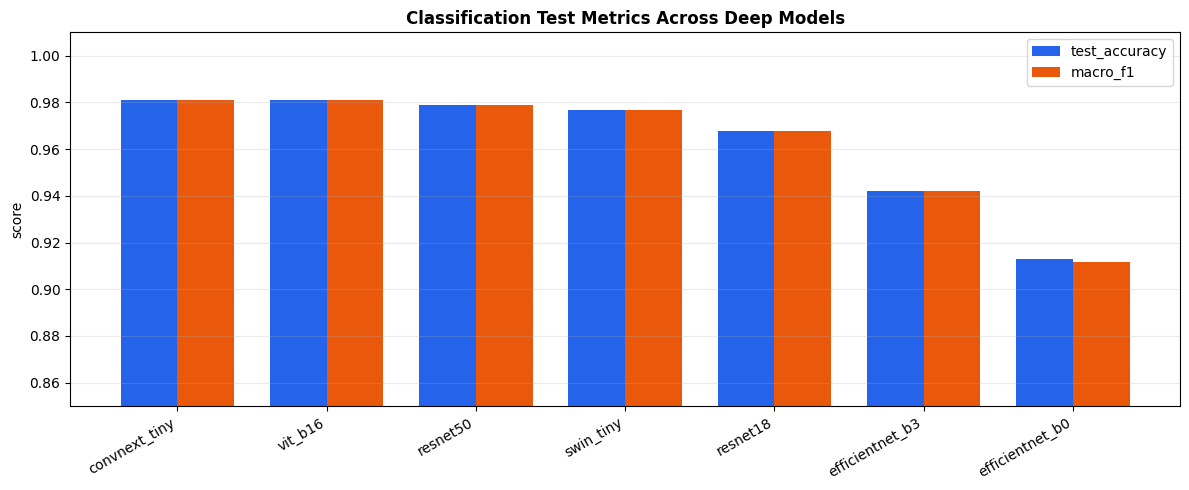

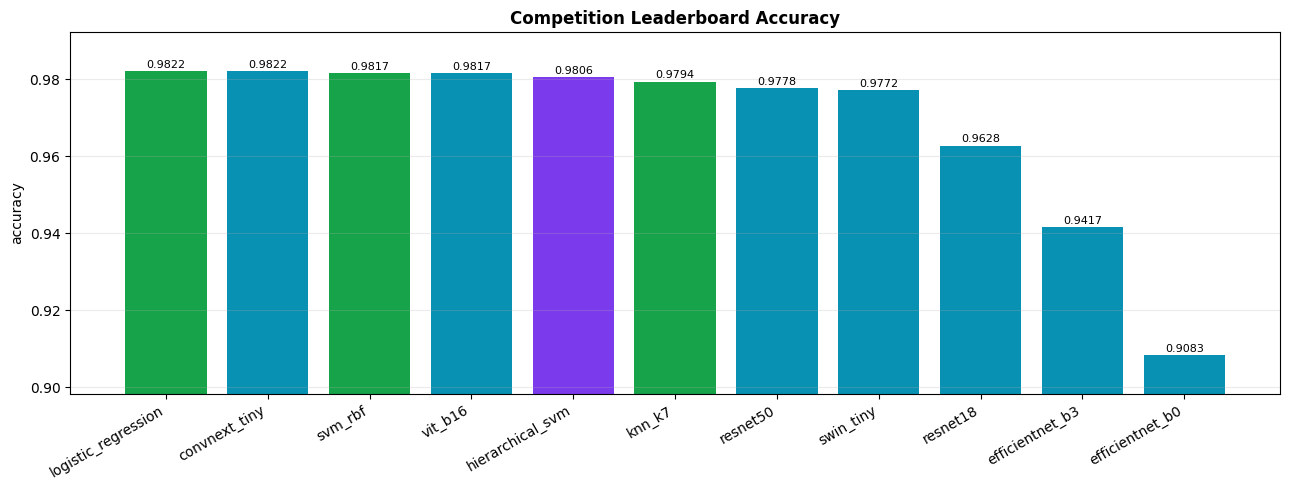

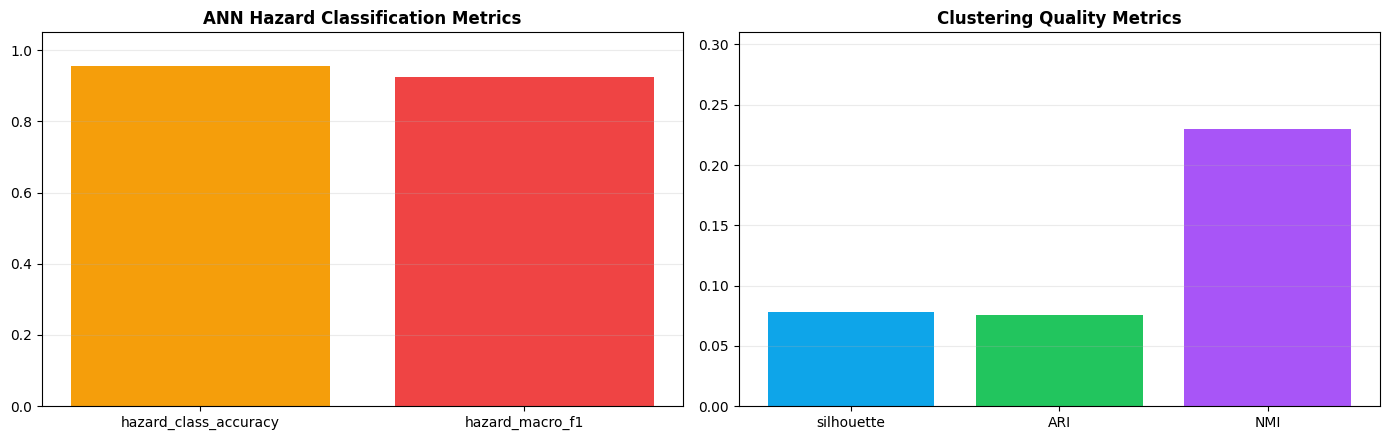

In [8]:
def _num(value):
    return value if isinstance(value, (int, float)) else None


def plot_classification_summary(test_payload):
    if not isinstance(test_payload, dict) or not test_payload:
        print("No classification summary payload found.")
        return

    rows = []
    for model_name, payload in test_payload.items():
        if not isinstance(payload, dict):
            continue
        acc = _num(payload.get("test_accuracy"))
        macro_f1 = _num(payload.get("macro_f1"))
        if acc is None or macro_f1 is None:
            metrics = payload.get("metrics", {}) if isinstance(payload, dict) else {}
            acc = _num(metrics.get("accuracy")) if acc is None else acc
            macro_f1 = _num(metrics.get("macro_f1")) if macro_f1 is None else macro_f1
        if acc is None or macro_f1 is None:
            continue
        rows.append((model_name, float(acc), float(macro_f1)))

    if not rows:
        print("Classification summary has no plottable numeric metrics.")
        return

    rows.sort(key=lambda item: item[1], reverse=True)
    model_names = [item[0] for item in rows]
    acc_scores = [item[1] for item in rows]
    f1_scores = [item[2] for item in rows]
    x = np.arange(len(model_names))
    width = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, acc_scores, width=width, label="test_accuracy", color="#2563eb")
    plt.bar(x + width / 2, f1_scores, width=width, label="macro_f1", color="#ea580c")
    plt.xticks(x, model_names, rotation=30, ha="right")
    plt.ylim(0.85, 1.01)
    plt.ylabel("score")
    plt.title("Classification Test Metrics Across Deep Models", fontweight="bold")
    plt.grid(axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_competition_leaderboard(leaderboard_payload):
    if not isinstance(leaderboard_payload, dict):
        print("No competition leaderboard payload found.")
        return
    ranking = leaderboard_payload.get("ranking")
    if not isinstance(ranking, list) or not ranking:
        print("Competition leaderboard ranking is empty.")
        return

    rows = []
    for item in ranking:
        if not isinstance(item, dict):
            continue
        acc = _num(item.get("accuracy"))
        if acc is None:
            continue
        rows.append((item.get("model", "unknown"), float(acc), item.get("model_type", "unknown")))

    if not rows:
        print("Competition leaderboard has no numeric accuracy values.")
        return

    labels = [item[0] for item in rows]
    values = [item[1] for item in rows]
    model_types = [item[2] for item in rows]
    palette = {
        "deep_learning": "#0891b2",
        "traditional_ml": "#16a34a",
        "hierarchical": "#7c3aed",
    }
    colors = [palette.get(model_type, "#64748b") for model_type in model_types]

    plt.figure(figsize=(13, 5))
    bars = plt.bar(labels, values, color=colors)
    plt.ylim(min(values) - 0.01, max(values) + 0.01)
    plt.ylabel("accuracy")
    plt.title("Competition Leaderboard Accuracy", fontweight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.25)
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, value + 0.0003, f"{value:.4f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_ann_and_clustering(ann_payload, cluster_payload):
    _, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    ann_cls = ann_payload.get("classification_metrics", {}) if isinstance(ann_payload, dict) else {}
    ann_labels = ["hazard_class_accuracy", "hazard_macro_f1"]
    ann_values = [
        _num(ann_cls.get("hazard_class_accuracy")),
        _num(ann_cls.get("hazard_macro_f1")),
    ]
    if all(value is not None for value in ann_values):
        axes[0].bar(ann_labels, ann_values, color=["#f59e0b", "#ef4444"])
        axes[0].set_ylim(0, 1.05)
        axes[0].set_title("ANN Hazard Classification Metrics", fontweight="bold")
        axes[0].grid(axis="y", alpha=0.25)
    else:
        axes[0].text(0.5, 0.5, "ANN classification metrics missing", ha="center", va="center")
        axes[0].set_axis_off()

    if isinstance(cluster_payload, dict):
        cluster_metrics = {
            "silhouette": _num(cluster_payload.get("silhouette_score")),
            "ARI": _num(cluster_payload.get("adjusted_rand_index")),
            "NMI": _num(cluster_payload.get("normalized_mutual_info")),
        }
    else:
        cluster_metrics = {}

    valid_cluster = {k: v for k, v in cluster_metrics.items() if v is not None}
    if valid_cluster:
        axes[1].bar(list(valid_cluster.keys()), list(valid_cluster.values()), color=["#0ea5e9", "#22c55e", "#a855f7"])
        axes[1].set_ylim(0, max(valid_cluster.values()) + 0.08)
        axes[1].set_title("Clustering Quality Metrics", fontweight="bold")
        axes[1].grid(axis="y", alpha=0.25)
    else:
        axes[1].text(0.5, 0.5, "Clustering metrics missing", ha="center", va="center")
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()


plot_classification_summary(classification_metrics)
plot_competition_leaderboard(competition_leaderboard)
plot_ann_and_clustering(ann_metrics, clustering_metrics)

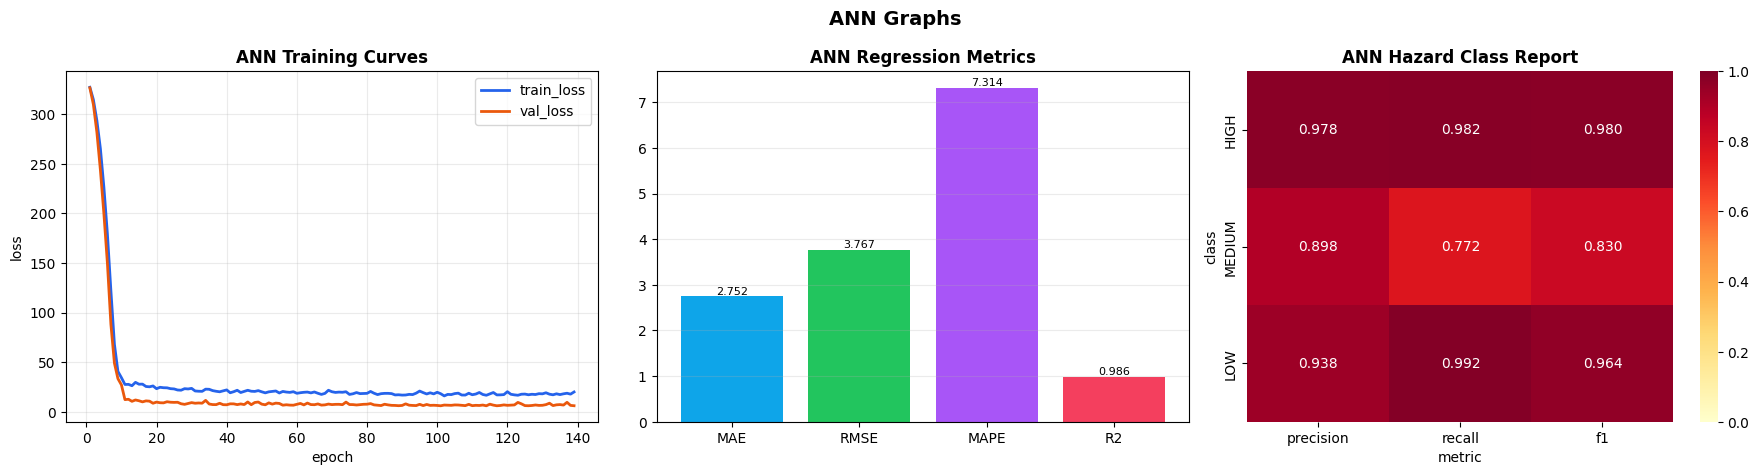

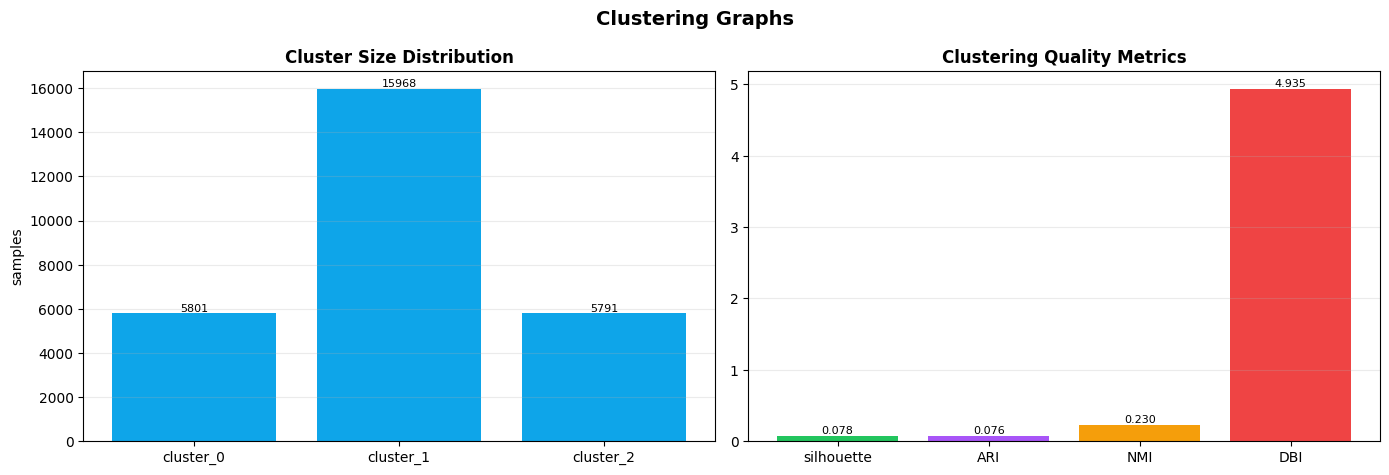

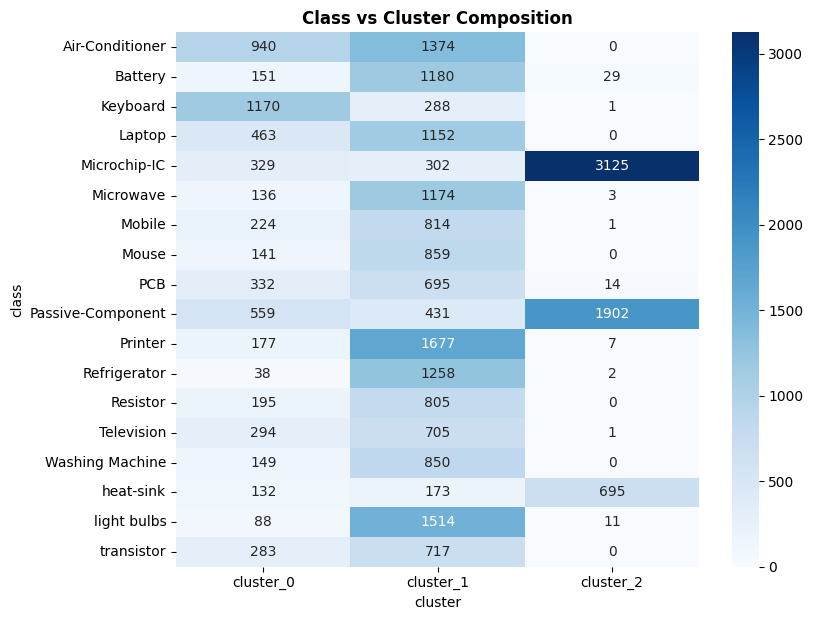

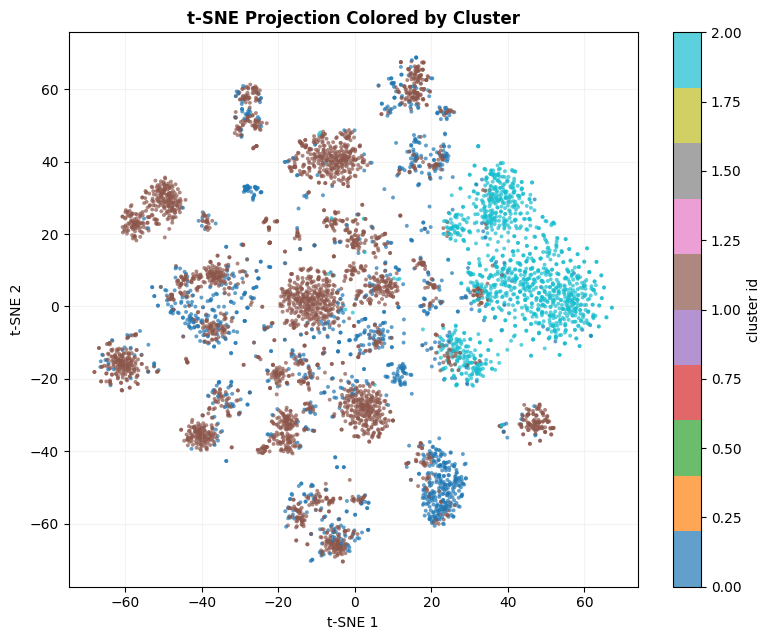

In [10]:
def _to_float(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    return None


def _safe_load_npy(path: Path):
    if not path.exists():
        return None
    try:
        return np.load(path, allow_pickle=False)
    except Exception as exc:
        print(f"Unable to load {path.name}: {exc}")
        return None


def plot_ann_research_graphs(ann_payload):
    if not isinstance(ann_payload, dict):
        print("ANN payload missing.")
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    history = ann_payload.get("history", {}) if isinstance(ann_payload, dict) else {}
    train_loss = history.get("train") if isinstance(history, dict) else None
    val_loss = history.get("val") if isinstance(history, dict) else None
    if isinstance(train_loss, list) and isinstance(val_loss, list) and train_loss and val_loss:
        n = min(len(train_loss), len(val_loss))
        epochs = np.arange(1, n + 1)
        axes[0].plot(epochs, train_loss[:n], label="train_loss", color="#2563eb", linewidth=2.0)
        axes[0].plot(epochs, val_loss[:n], label="val_loss", color="#ea580c", linewidth=2.0)
        axes[0].set_title("ANN Training Curves", fontweight="bold")
        axes[0].set_xlabel("epoch")
        axes[0].set_ylabel("loss")
        axes[0].grid(alpha=0.25)
        axes[0].legend()
    else:
        axes[0].text(0.5, 0.5, "Training history unavailable", ha="center", va="center")
        axes[0].set_axis_off()

    reg = ann_payload.get("regression_metrics", {}) if isinstance(ann_payload, dict) else {}
    reg_items = []
    for key in ("mae", "rmse", "mape", "r2"):
        metric = _to_float(reg.get(key))
        if metric is not None:
            reg_items.append((key.upper(), metric))

    if reg_items:
        labels = [item[0] for item in reg_items]
        values = [item[1] for item in reg_items]
        bars = axes[1].bar(labels, values, color=["#0ea5e9", "#22c55e", "#a855f7", "#f43f5e"][: len(labels)])
        axes[1].set_title("ANN Regression Metrics", fontweight="bold")
        axes[1].grid(axis="y", alpha=0.25)
        for bar, value in zip(bars, values):
            axes[1].text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom", fontsize=8)
    else:
        axes[1].text(0.5, 0.5, "Regression metrics unavailable", ha="center", va="center")
        axes[1].set_axis_off()

    report = ann_payload.get("classification_report", {}) if isinstance(ann_payload, dict) else {}
    ann_classes = []
    for class_name, class_metrics in report.items():
        if not isinstance(class_metrics, dict):
            continue
        if class_name.lower() in {"macro avg", "weighted avg"}:
            continue
        row = [
            _to_float(class_metrics.get("precision")),
            _to_float(class_metrics.get("recall")),
            _to_float(class_metrics.get("f1-score")),
        ]
        if all(value is not None for value in row):
            ann_classes.append((class_name, row))

    if ann_classes:
        class_names = [item[0] for item in ann_classes]
        matrix = np.array([item[1] for item in ann_classes], dtype=float)
        sns.heatmap(
            matrix,
            annot=True,
            fmt=".3f",
            cmap="YlOrRd",
            vmin=0,
            vmax=1,
            xticklabels=["precision", "recall", "f1"],
            yticklabels=class_names,
            ax=axes[2],
        )
        axes[2].set_title("ANN Hazard Class Report", fontweight="bold")
        axes[2].set_xlabel("metric")
        axes[2].set_ylabel("class")
    else:
        axes[2].text(0.5, 0.5, "Classification report unavailable", ha="center", va="center")
        axes[2].set_axis_off()

    plt.suptitle("ANN Graphs", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def _build_cluster_composition_matrix(class_labels, cluster_labels, class_names=None):
    if class_labels is None or cluster_labels is None:
        return None, None, None
    if len(class_labels) != len(cluster_labels):
        return None, None, None

    cluster_ids = cluster_labels.astype(int)
    n_clusters = int(cluster_ids.max()) + 1 if len(cluster_ids) else 0
    if n_clusters <= 0:
        return None, None, None

    if np.issubdtype(class_labels.dtype, np.number):
        class_ids = class_labels.astype(int)
        unique_classes = np.unique(class_ids)
        class_to_row = {class_id: idx for idx, class_id in enumerate(unique_classes)}
        matrix = np.zeros((len(unique_classes), n_clusters), dtype=int)
        for class_id, cluster_id in zip(class_ids, cluster_ids):
            matrix[class_to_row[class_id], cluster_id] += 1

        if isinstance(class_names, list) and class_names and int(unique_classes.max()) < len(class_names):
            y_labels = [class_names[int(class_id)] for class_id in unique_classes]
        else:
            y_labels = [str(int(class_id)) for class_id in unique_classes]
    else:
        class_str = class_labels.astype(str)
        unique_classes = np.unique(class_str)
        class_to_row = {class_name: idx for idx, class_name in enumerate(unique_classes)}
        matrix = np.zeros((len(unique_classes), n_clusters), dtype=int)
        for class_name, cluster_id in zip(class_str, cluster_ids):
            matrix[class_to_row[class_name], cluster_id] += 1
        y_labels = [str(class_name) for class_name in unique_classes]

    x_labels = [f"cluster_{idx}" for idx in range(n_clusters)]
    return matrix, y_labels, x_labels


def plot_clustering_research_graphs(cluster_payload, max_points=8000):
    payload = cluster_payload if isinstance(cluster_payload, dict) else {}

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

    cluster_sizes = payload.get("cluster_sizes", {}) if isinstance(payload, dict) else {}
    if isinstance(cluster_sizes, dict) and cluster_sizes:
        parsed = []
        for key, value in cluster_sizes.items():
            size = _to_float(value)
            if size is None:
                continue
            try:
                cluster_idx = int(key)
            except Exception:
                cluster_idx = str(key)
            parsed.append((cluster_idx, int(size)))

        parsed.sort(key=lambda item: item[0])
        labels = [f"cluster_{item[0]}" for item in parsed]
        values = [item[1] for item in parsed]
        bars = axes[0].bar(labels, values, color="#0ea5e9")
        axes[0].set_title("Cluster Size Distribution", fontweight="bold")
        axes[0].set_ylabel("samples")
        axes[0].grid(axis="y", alpha=0.25)
        for bar, value in zip(bars, values):
            axes[0].text(bar.get_x() + bar.get_width() / 2, value, f"{value}", ha="center", va="bottom", fontsize=8)
    else:
        axes[0].text(0.5, 0.5, "Cluster sizes unavailable", ha="center", va="center")
        axes[0].set_axis_off()

    quality = {
        "silhouette": _to_float(payload.get("silhouette_score")),
        "ARI": _to_float(payload.get("adjusted_rand_index")),
        "NMI": _to_float(payload.get("normalized_mutual_info")),
        "DBI": _to_float(payload.get("davies_bouldin_index")),
    }
    plotted = [(k, v) for k, v in quality.items() if v is not None]
    if plotted:
        labels = [item[0] for item in plotted]
        values = [item[1] for item in plotted]
        bars = axes[1].bar(labels, values, color=["#22c55e", "#a855f7", "#f59e0b", "#ef4444"][: len(labels)])
        axes[1].set_title("Clustering Quality Metrics", fontweight="bold")
        axes[1].grid(axis="y", alpha=0.25)
        for bar, value in zip(bars, values):
            axes[1].text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom", fontsize=8)
    else:
        axes[1].text(0.5, 0.5, "Clustering quality metrics unavailable", ha="center", va="center")
        axes[1].set_axis_off()

    plt.suptitle("Clustering Graphs", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    cluster_meta = load_json(CLUSTER_DIR / "clustering_results.json")
    class_names = cluster_meta.get("class_names") if isinstance(cluster_meta, dict) else None
    class_labels = _safe_load_npy(CLUSTER_DIR / "labels.npy")
    cluster_labels = _safe_load_npy(CLUSTER_DIR / "cluster_labels.npy")

    composition_matrix, y_labels, x_labels = _build_cluster_composition_matrix(
        class_labels,
        cluster_labels,
        class_names=class_names,
    )
    if composition_matrix is not None:
        plt.figure(figsize=(8.5, max(4.5, len(y_labels) * 0.35)))
        sns.heatmap(
            composition_matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=x_labels,
            yticklabels=y_labels,
        )
        plt.title("Class vs Cluster Composition", fontweight="bold")
        plt.xlabel("cluster")
        plt.ylabel("class")
        plt.tight_layout()
        plt.show()
    else:
        print("Class-vs-cluster composition plot skipped (missing labels.npy or cluster_labels.npy).")

    tsne = _safe_load_npy(CLUSTER_DIR / "tsne_result.npy")
    tsne_clusters = _safe_load_npy(CLUSTER_DIR / "tsne_clusters.npy")

    if (
        tsne is not None
        and tsne_clusters is not None
        and tsne.ndim == 2
        and tsne.shape[1] >= 2
        and len(tsne) == len(tsne_clusters)
    ):
        total_points = len(tsne)
        if total_points > max_points:
            rng = np.random.default_rng(42)
            idx = rng.choice(total_points, size=max_points, replace=False)
        else:
            idx = np.arange(total_points)

        pts = tsne[idx, :2]
        cluster_ids = tsne_clusters[idx].astype(int)

        plt.figure(figsize=(8, 6.5))
        scatter = plt.scatter(
            pts[:, 0],
            pts[:, 1],
            c=cluster_ids,
            cmap="tab10",
            s=8,
            alpha=0.7,
            linewidths=0,
        )
        cbar = plt.colorbar(scatter)
        cbar.set_label("cluster id")
        plt.title("t-SNE Projection Colored by Cluster", fontweight="bold")
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.grid(alpha=0.15)
        plt.tight_layout()
        plt.show()
    else:
        print("t-SNE cluster scatter skipped (missing tsne_result.npy or tsne_clusters.npy).")


plot_ann_research_graphs(ann_metrics)
plot_clustering_research_graphs(clustering_metrics)

In [5]:
def discover_images(base_dir: Path):
    if not base_dir.exists():
        return []
    return sorted(
        [path for path in base_dir.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTS],
        key=lambda path: str(path.relative_to(PROJECT_ROOT)).lower(),
    )


def build_figure_groups():
    groups = {
        "Classification": [],
        "ANN Hazard Modeling": [],
        "Clustering": [],
        "Competition": [],
        "Other": [],
    }
    excluded_names = {"confusion_matrices_18cls.png"}

    for path in discover_images(MODELS_DIR):
        if path.name.lower() in excluded_names:
            continue

        rel = path.relative_to(MODELS_DIR)
        top_level = rel.parts[0].lower() if rel.parts else ""
        if top_level == "classification":
            group_name = "Classification"
        elif top_level == "ann":
            group_name = "ANN Hazard Modeling"
        elif top_level == "clustering":
            group_name = "Clustering"
        elif top_level == "competition":
            group_name = "Competition"
        else:
            group_name = "Other"
        groups[group_name].append(path)

    deduped_groups = {}
    for group_name, files in groups.items():
        deduped = []
        seen = set()
        for path in files:
            key = str(path.resolve())
            if key not in seen:
                deduped.append(path)
                seen.add(key)
        if deduped:
            deduped_groups[group_name] = deduped

    return deduped_groups


figure_groups = build_figure_groups()
for group_name, files in figure_groups.items():
    print(f"{group_name}: {len(files)} figure(s)")
    for path in files:
        print(" -", path.relative_to(PROJECT_ROOT))

print("\nconfusion_matrices_18cls.png is excluded from image gallery")
print("because the notebook now renders up-to-date annotated confusion matrices directly from classification results JSON.")

Classification: 4 figure(s)
 - models\classification\graphs\gradcam_all_classes.png
 - models\classification\graphs\per_class_f1_comparison.png
 - models\classification\graphs\training_curves.png
 - models\classification\graphs\training_curves_18cls.png

confusion_matrices_18cls.png is excluded from image gallery
because the notebook now renders up-to-date annotated confusion matrices directly from classification results JSON.


In [6]:
def show_graph(path: Path, title: str | None = None) -> None:
    if not path.exists():
        print(f"missing: {path.name}")
        return

    try:
        image = Image.open(path)
    except Exception as exc:
        print(f"unable to open {path.name}: {exc}")
        return

    width, height = image.size
    plt.figure(figsize=(min(18, max(8, width / 110)), min(12, max(4, height / 110))))
    plt.imshow(image)
    plt.title(title or path.name, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.show()


Classification


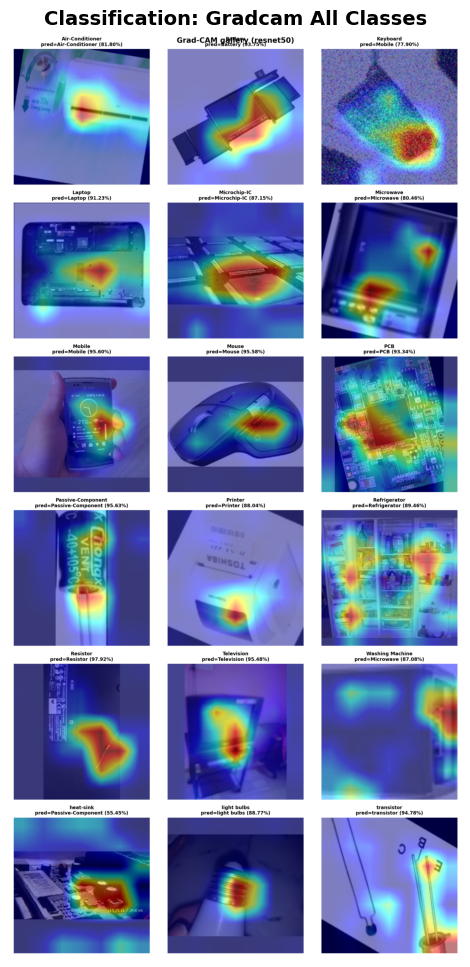

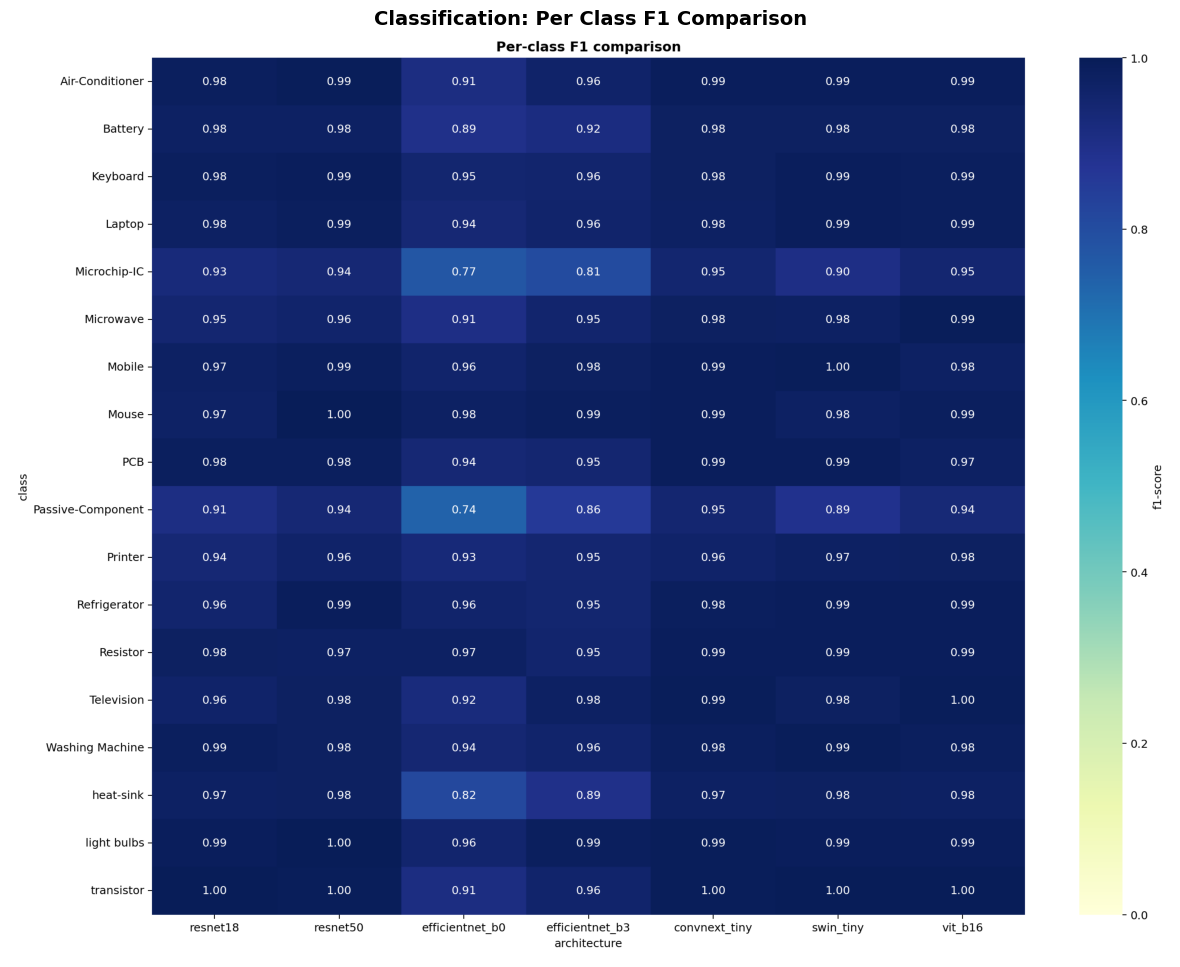

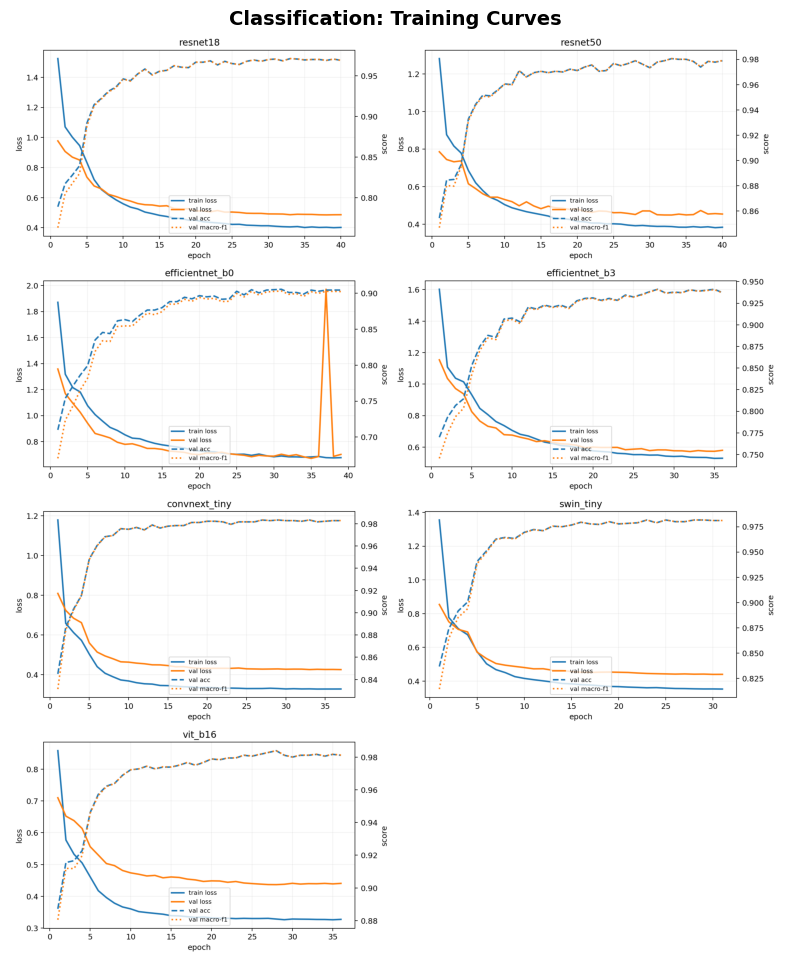

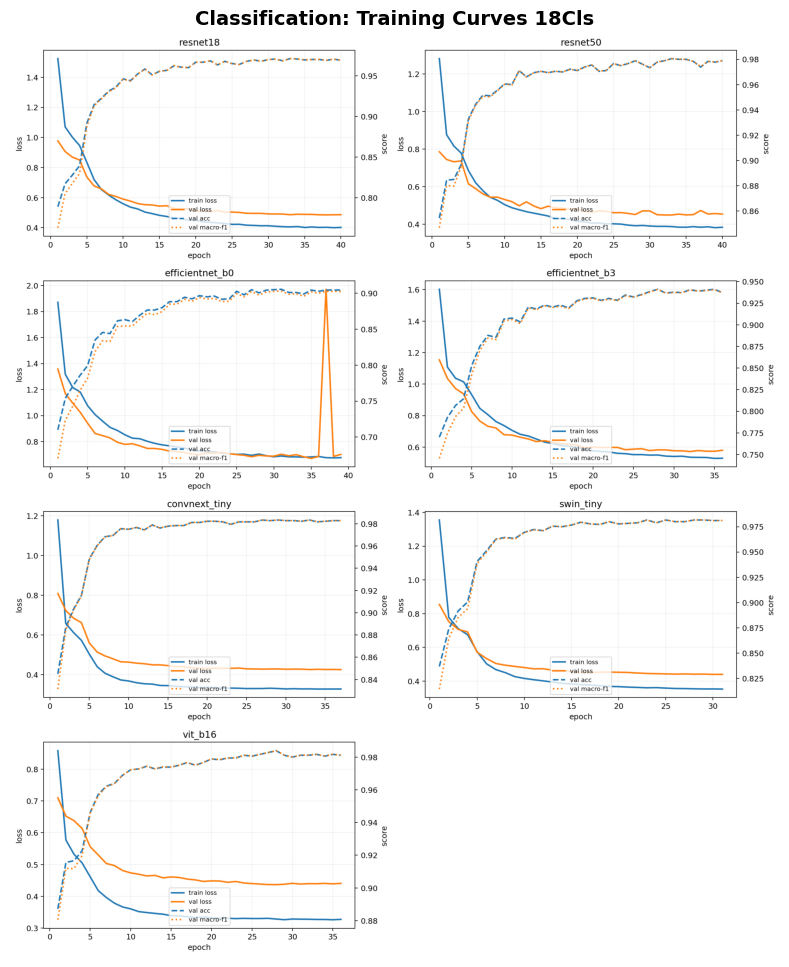

In [7]:
for group_name, files in figure_groups.items():
    print("\n" + "=" * 80)
    print(group_name)
    print("=" * 80)
    if not files:
        print("no saved figures found")
        continue
    for path in files:
        show_graph(path, f"{group_name}: {path.stem.replace('_', ' ').title()}")